In [ ]:
# DATASET LOADING & BASIC INSPECTION
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


dataset = pd.read_csv('Career_Switch_Prediction_Dataset.csv')
dataset.columns = dataset.columns.str.strip()

# Drop irrelevant ID columns
dataset = dataset.drop(columns=['enrollee_id', 'city'], errors='ignore') #overfitting issue can occur

dataset.head()

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [ ]:
dataset.shape # 5000 dataset and 12 columns

(5000, 12)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  5000 non-null   float64
 1   gender                  3887 non-null   object 
 2   relevent_experience     5000 non-null   object 
 3   enrolled_university     4893 non-null   object 
 4   education_level         4882 non-null   object 
 5   major_discipline        4276 non-null   object 
 6   experience              4989 non-null   object 
 7   company_size            3429 non-null   object 
 8   company_type            3379 non-null   object 
 9   last_new_job            4896 non-null   object 
 10  training_hours          5000 non-null   int64  
 11  will_change_career      5000 non-null   int64  
dtypes: float64(1), int64(2), object(9)
memory usage: 468.9+ KB


In [ ]:
# DATASET DESCRIPTION (FEATURE TYPES)
numerical_features = dataset.select_dtypes(include='number').columns.tolist()
if 'will_change_career' in numerical_features:
    numerical_features.remove('will_change_career')

categorical_features = dataset.select_dtypes(include='object').columns.tolist()

print(f'There are {len(categorical_features)} categorial features:')
print(categorical_features)
print()
print(f'There are {len(numerical_features)} numerical features:')
print(numerical_features)

There are 9 categorial features:
['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']

There are 2 numerical features:
['city_development_index', 'training_hours']


In [ ]:
# CHECK FOR MISSING VALUES
dataset.isnull().sum()

,0
city_development_index,0
gender,1113
relevent_experience,0
enrolled_university,107
education_level,118
major_discipline,724
experience,11
company_size,1571
company_type,1621
last_new_job,104


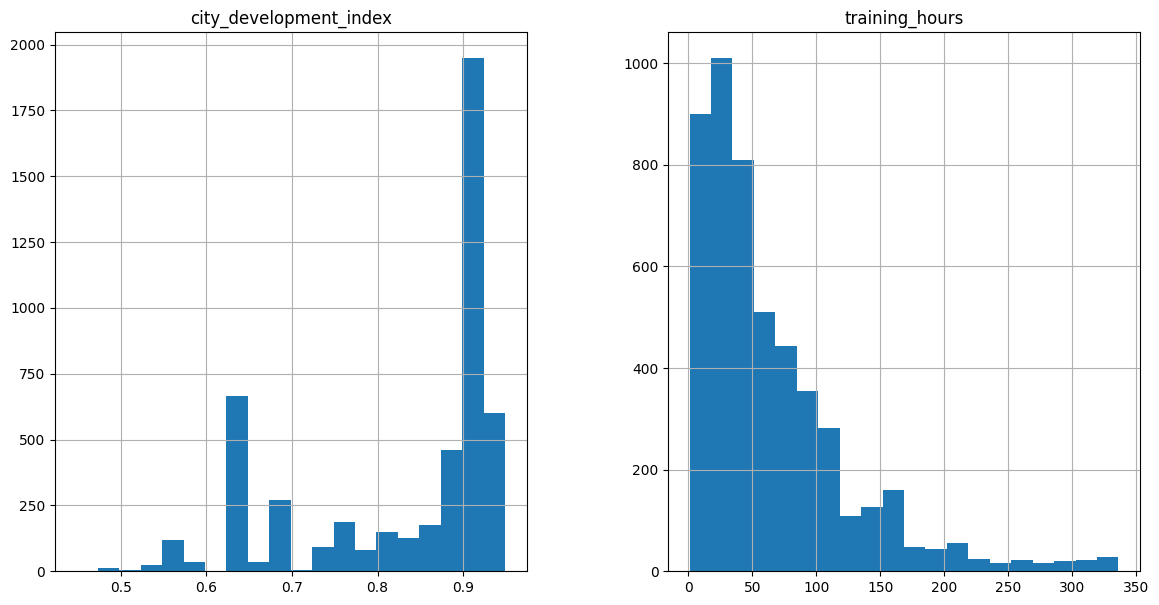

In [ ]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# 4.1 Distribution of Numerical Features
import matplotlib.pyplot as plt

dataset[numerical_features].hist(figsize=(14,7), bins=20)
plt.show()

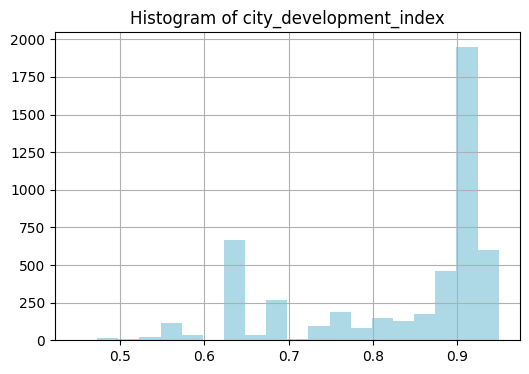

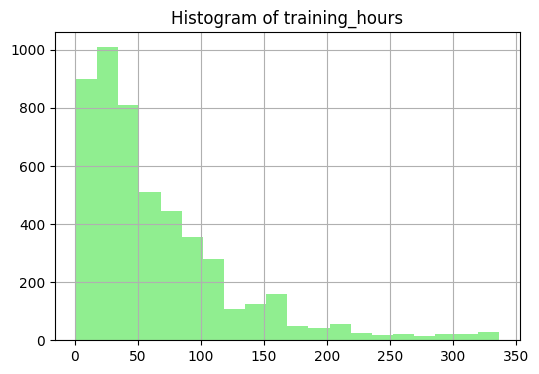

In [ ]:
import matplotlib.pyplot as plt

# Graph for city_development_index
plt.figure(figsize=(6,4))
dataset['city_development_index'].hist(bins=20, color='lightblue')
plt.title('Histogram of city_development_index')
plt.show()

# Graph for training_hours
plt.figure(figsize=(6,4))
dataset['training_hours'].hist(bins=20, color='lightgreen')
plt.title('Histogram of training_hours')
plt.show()

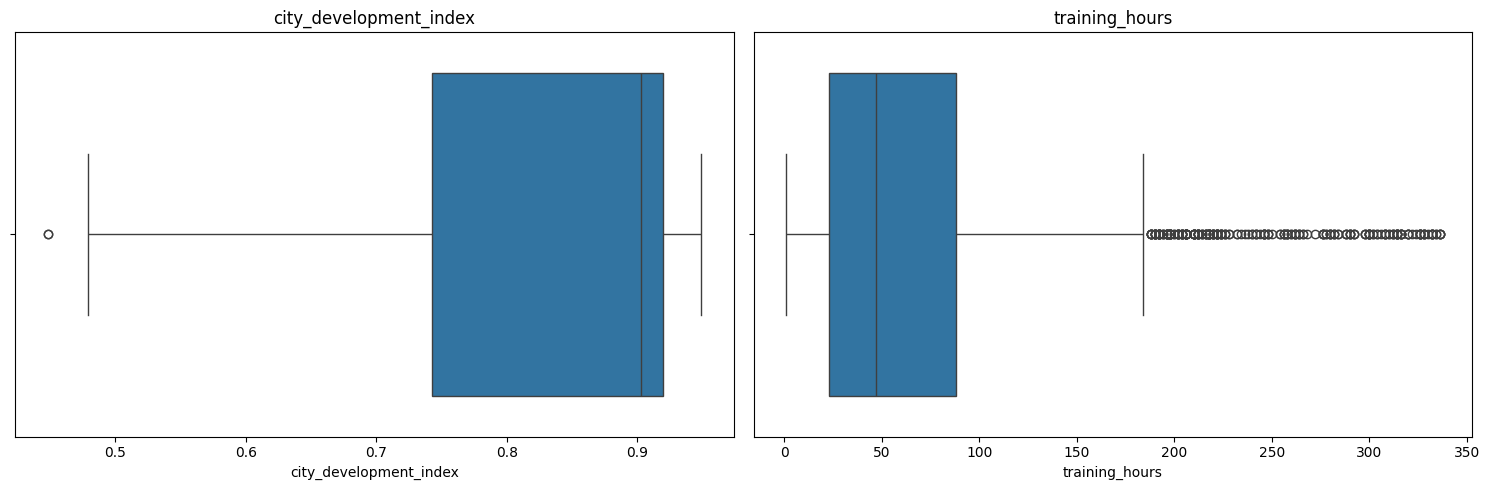

In [ ]:
# 4.2 Outlier Detection (Boxplots)
import seaborn as sns

plt.figure(figsize=(15,5))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, len(numerical_features), i)
    sns.boxplot(x=dataset[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

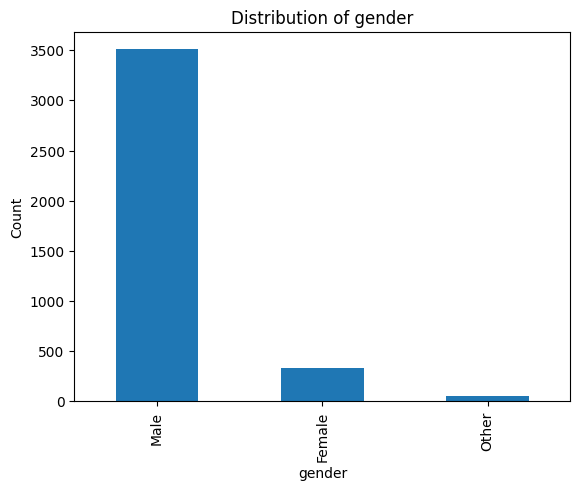

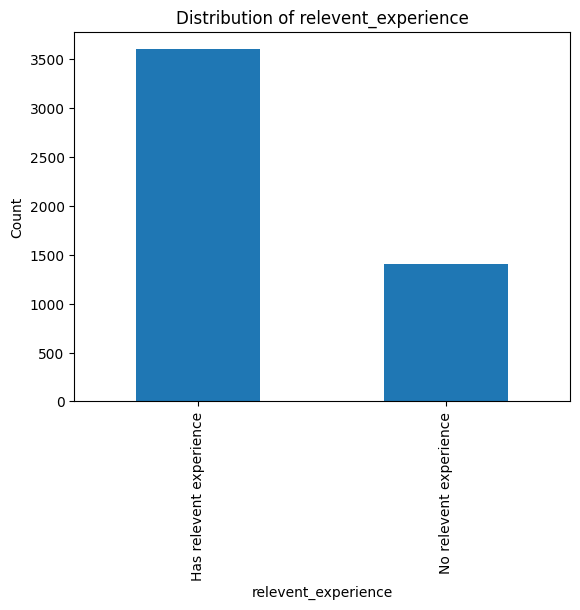

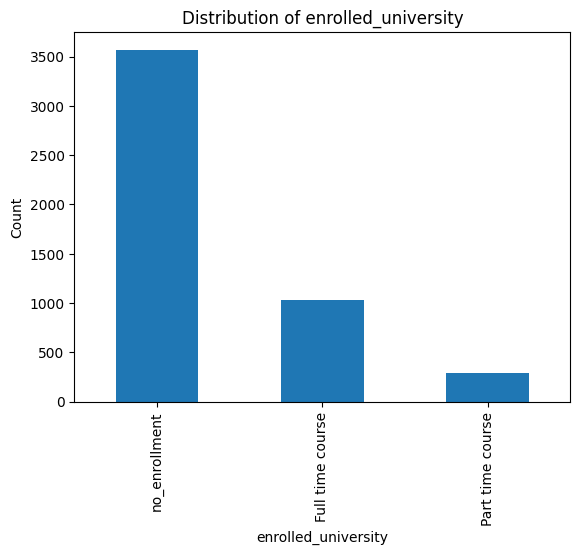

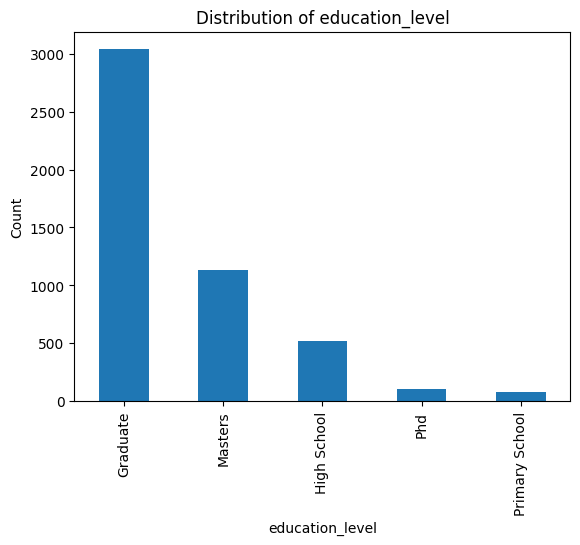

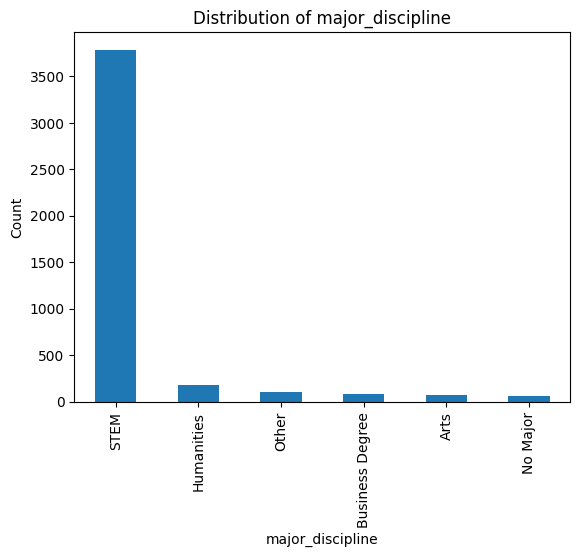

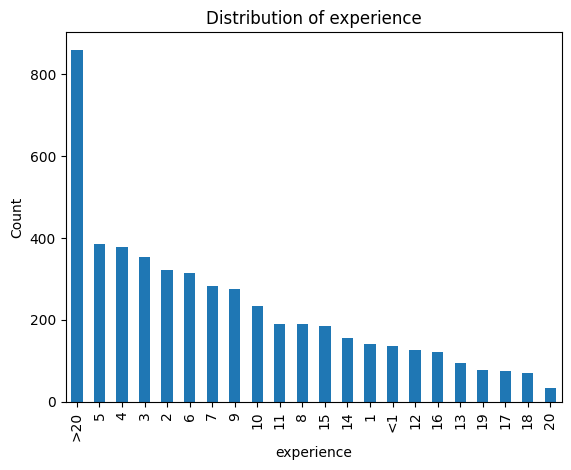

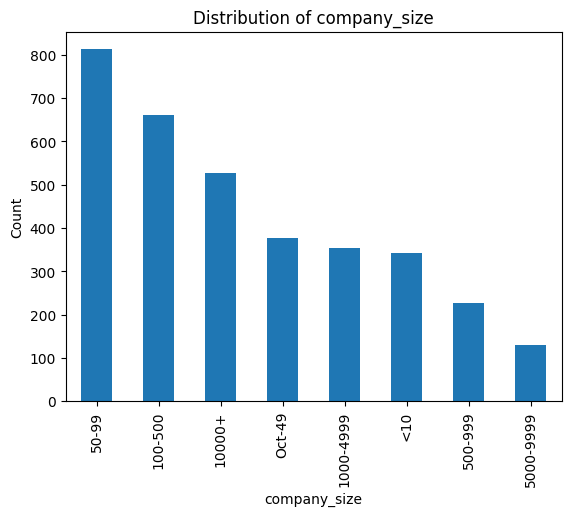

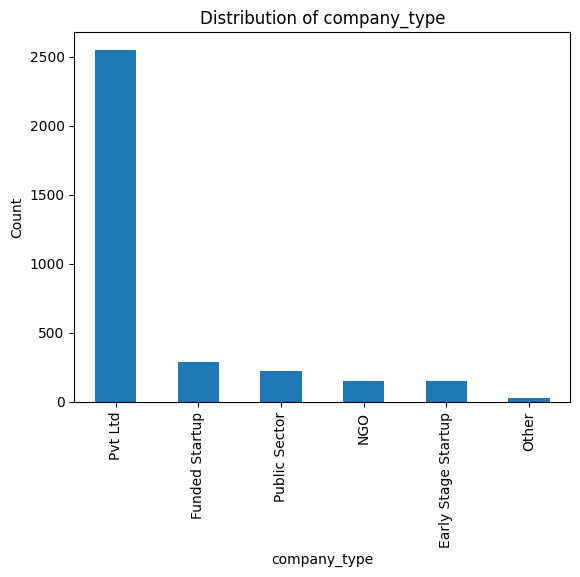

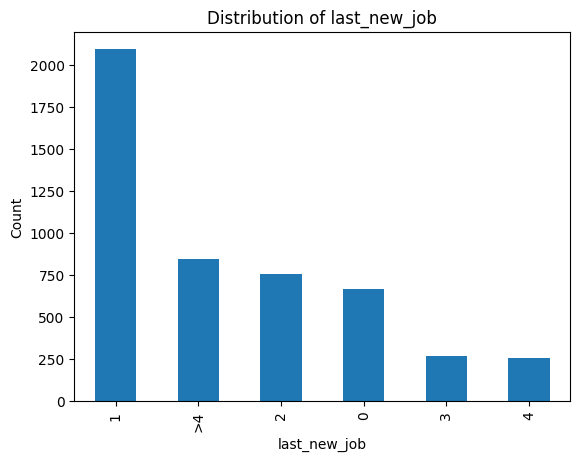

In [ ]:
# 4.3 Categorical Feature Distribution
for col in categorical_features:
    if col in dataset.columns:
        dataset[col].value_counts().plot(kind='bar')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

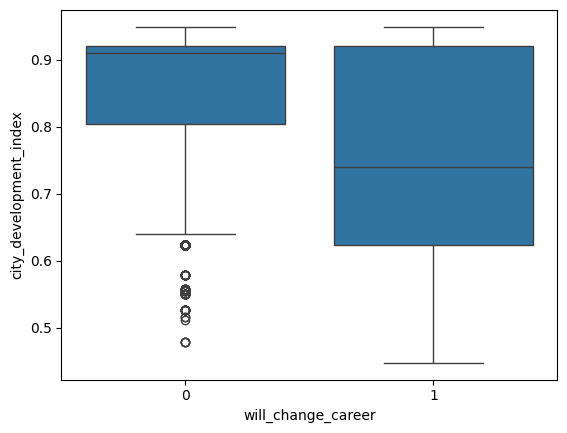

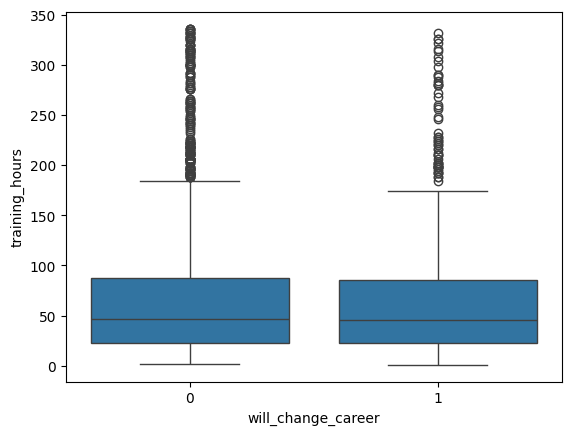

In [ ]:
# 4.4 Feature vs Target Relationship
for col in numerical_features:
    sns.boxplot(x='will_change_career', y=col, data=dataset)
    plt.show()

In [ ]:
# 5. CORRELATION ANALYSIS
# 5.1 Encoding Before Correlation
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Fill nulls in categorical before encoding
for col in categorical_features:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

# Label Encode ordinal features
for col in ['education_level', 'experience', 'company_size', 'last_new_job']:
    if col in dataset.columns:
        dataset[col] = LabelEncoder().fit_transform(dataset[col])

# Dummy Encode nominal features
nominal_cols = [col for col in categorical_features if col not in ['education_level', 'experience', 'company_size', 'last_new_job']]
dataset = pd.get_dummies(dataset, columns=nominal_cols, drop_first=True) #drop_ first to remove multicollinearity

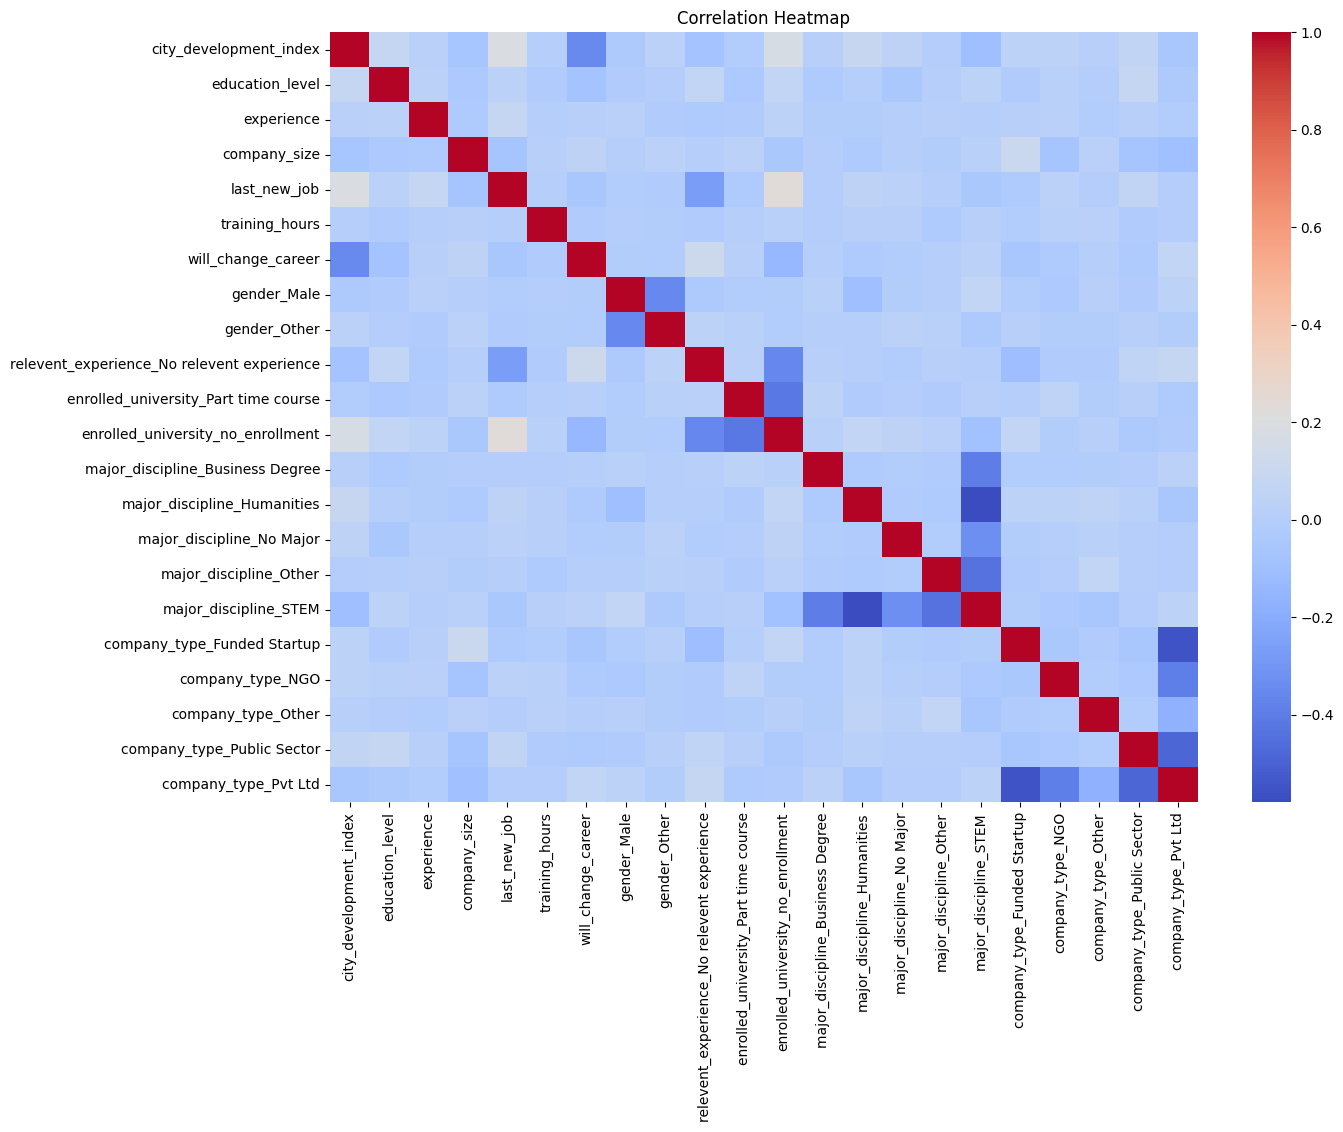

In [ ]:
# 5.2 Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(dataset.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# 6. IMBALANCED DATASET CHECK
dataset['will_change_career'].value_counts()

,count
will_change_career,
0,3738
1,1262


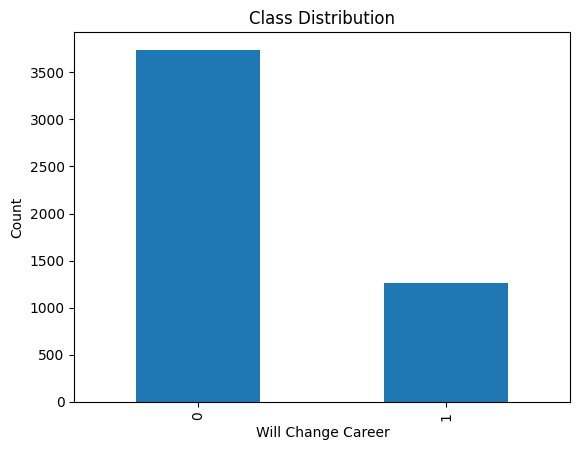

In [ ]:
dataset['will_change_career'].value_counts().plot(kind='bar')
plt.xlabel('Will Change Career')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [ ]:
# 7. DATASET PRE-PROCESSING
# 7.1 Handling Missing Values
for col in numerical_features:
    dataset[col] = dataset[col].fillna(dataset[col].median()) #training_hours value is right skewed and has too many outliers so we used median instead of mean

In [ ]:
# 7.2 Feature Scaling
from sklearn.preprocessing import StandardScaler

X = dataset.drop(columns=['will_change_career'])
y = dataset['will_change_career']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 8. DATASET SPLITTING
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y, #dataset imbalanced
    random_state=42 #seed value it maintains data to split in same way
)

In [ ]:
# 9. SUPERVISED MODEL TRAINING
# 9.1 Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced') #handle extreme class imbalance
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

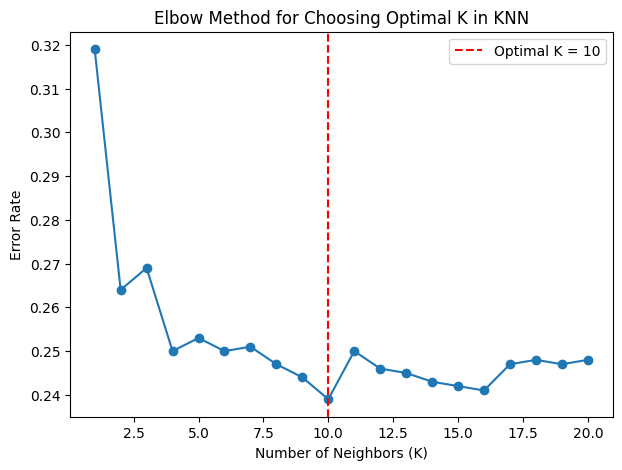

In [ ]:
# 9.2 K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score #used to check closest employees characters if they want to change career

k_values = range(1, 21)
error_rates = []

# Train KNN for different K values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred)
    error_rates.append(error)

# Find elbow point (minimum error)
optimal_k = k_values[np.argmin(error_rates)]

# Plot Elbow Curve
plt.figure(figsize=(7,5))
plt.plot(k_values, error_rates, marker='o')
plt.axvline(x=optimal_k, linestyle='--', color='red', label=f'Optimal K = {optimal_k}')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")
plt.title("Elbow Method for Choosing Optimal K in KNN")
plt.legend()
plt.show()

# Retrain with optimal K
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
# 9.5 Neural Network
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=200)
nn.fit(X_train, y_train)

y_pred_nn = nn.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


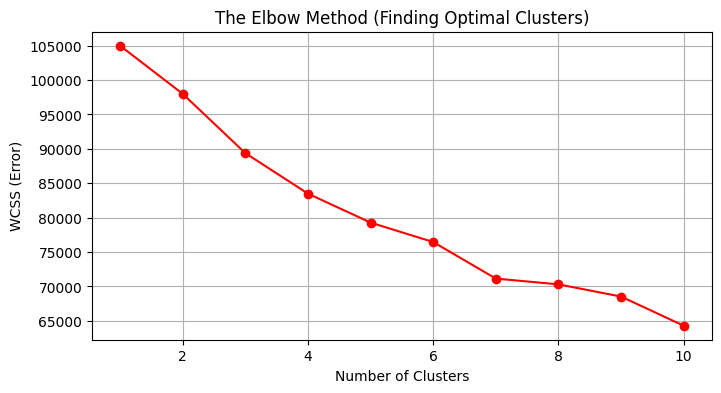

In [ ]:
# 10. UNSUPERVISED LEARNING (K-MEANS)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=i, init='k-means++', random_state=42) #WCSS (Within-Cluster Sum of Squares) drew elbow graph
    kmeans_elbow.fit(X_scaled)
    wcss.append(kmeans_elbow.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('The Elbow Method (Finding Optimal Clusters)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Error)')
plt.grid(True)
plt.show()
# ------------------------------

In [ ]:
# 11. MODEL EVALUATION
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np

y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_nn = nn.predict_proba(X_test)[:, 1]

evaluation_df = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nn)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nn)
    ],
    "AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_nn)
    ]
})

evaluation_df

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.707,0.442577,0.626984,0.518883,0.716424
1,KNN,0.761,0.551181,0.277778,0.369393,0.694166
2,Neural Network,0.728,0.452830,0.380952,0.413793,0.686715


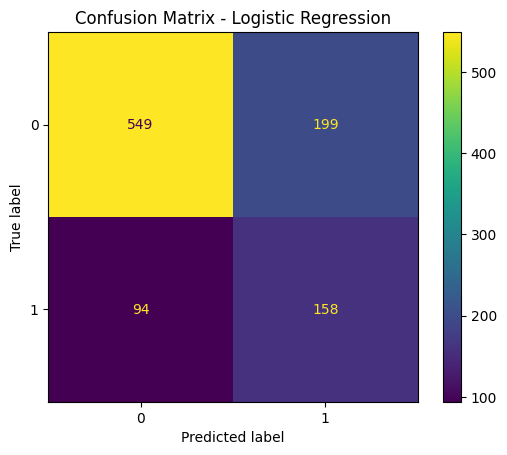

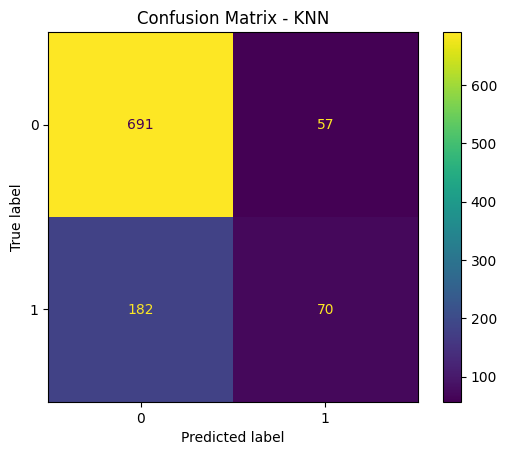

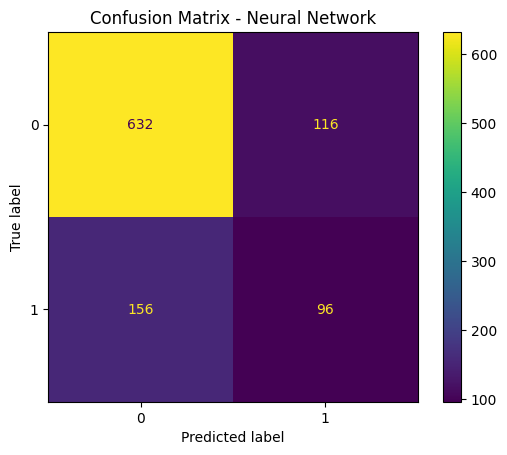

In [ ]:
models_preds = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Neural Network": y_pred_nn
}

for model_name, preds in models_preds.items():
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

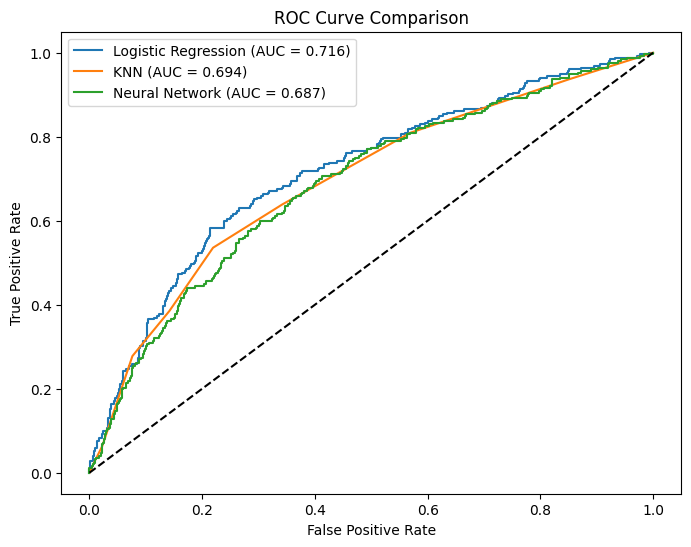

In [ ]:
plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_score(y_test, y_prob_knn):.3f})")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {roc_auc_score(y_test, y_prob_nn):.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

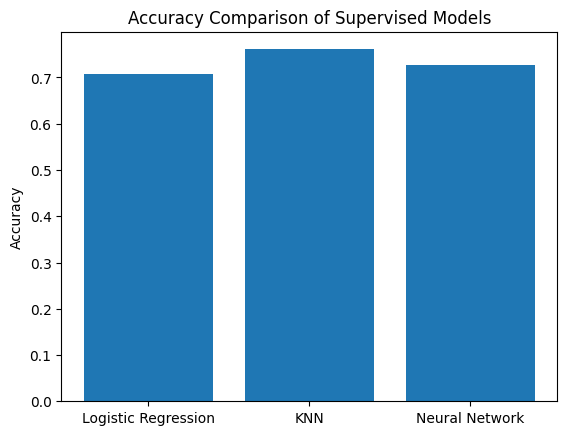

In [ ]:
plt.bar(evaluation_df["Model"], evaluation_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Supervised Models")
plt.show()

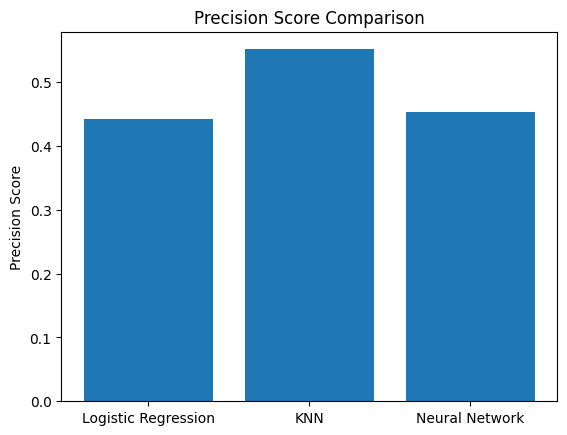

In [ ]:
precision_scores = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_nn)
]
models = ["Logistic Regression", "KNN", "Neural Network"]
plt.bar(models, precision_scores)
plt.ylabel("Precision Score")
plt.title("Precision Score Comparison")
plt.show()

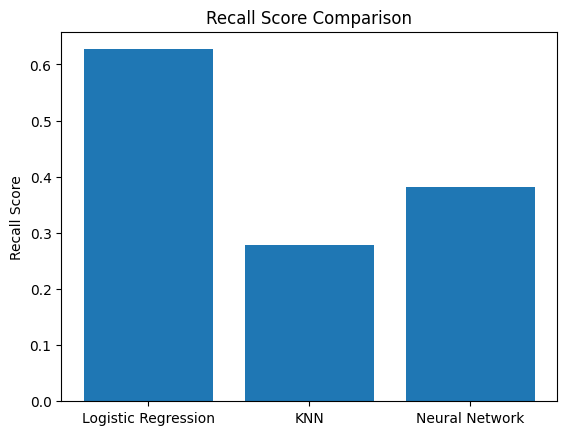

In [ ]:
from sklearn.metrics import recall_score
recall_scores = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_nn)
]
plt.bar(models, recall_scores)
plt.ylabel("Recall Score")
plt.title("Recall Score Comparison")
plt.show()

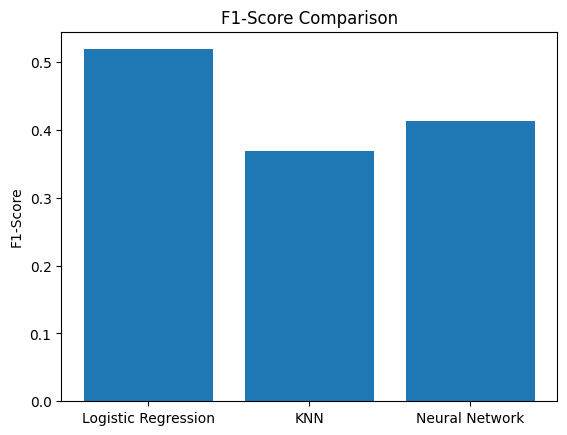

In [ ]:
from sklearn.metrics import f1_score
f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_nn)
]
plt.bar(models, f1_scores)
plt.ylabel("F1-Score")
plt.title("F1-Score Comparison")
plt.show()

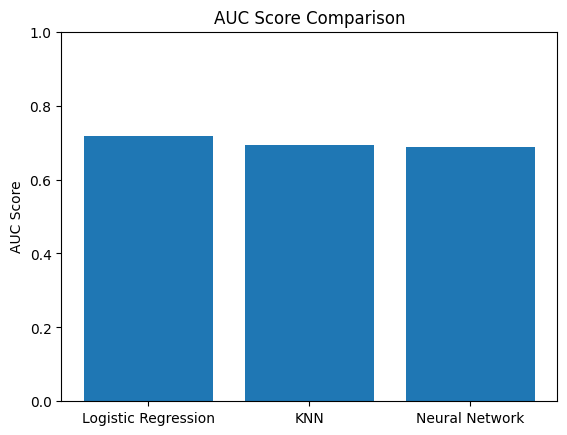

In [ ]:
auc_scores = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_knn),
    roc_auc_score(y_test, y_prob_nn)
]
models = ["Logistic Regression", "KNN", "Neural Network"]
plt.bar(models, auc_scores)
plt.ylabel("AUC Score")
plt.title("AUC Score Comparison")
plt.ylim(0, 1)
plt.show()

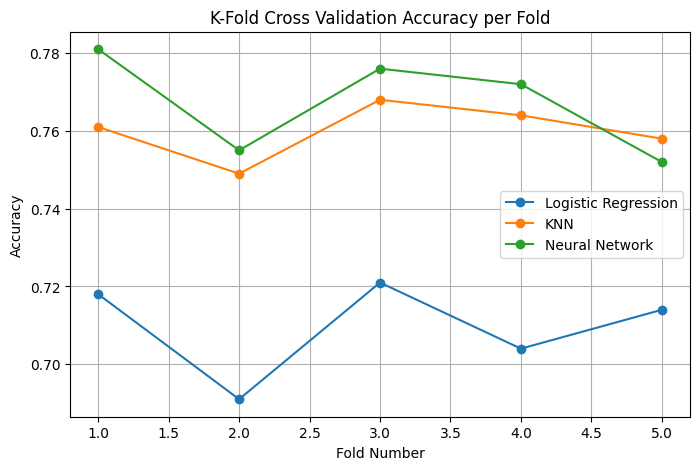

In [ ]:
# 12. K-FOLD CROSS VALIDATION
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_cv = X_scaled
y_cv = y

# Stratified 5-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=300, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=optimal_k),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(32,16), max_iter=50, random_state=42)
}

fold_accuracies = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_cv,
        y_cv,
        cv=kf,
        scoring='accuracy',
        n_jobs=-1
    )
    fold_accuracies[name] = scores

# Plot
plt.figure(figsize=(8,5))
folds = np.arange(1, 6)

for name, scores in fold_accuracies.items():
    plt.plot(folds, scores, marker='o', label=name)

plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("K-Fold Cross Validation Accuracy per Fold")
plt.legend()
plt.grid(True)
plt.show()